# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [22]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import keras.applications as ka
import keras
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import time

## Task 1
Implement the my_team()function 

In [23]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [
        ('n11285915', 'Nour', 'Spear'),
        ('n11323442', 'Joshua', 'Oates'),
        ('n12116785', 'Joshua', 'George'),
    ]

In [24]:
my_team()

[('n11285915', 'Nour', 'Spear'),
 ('n11323442', 'Joshua', 'Oates'),
 ('n12116785', 'Joshua', 'George')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [25]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Returns:
        X: numpy array of shape (n_samples, 224, 224, 3)
        Y: numpy array of shape (n_samples,)
    '''
    # ensures imported path is in the correct file system format
    data_root = os.fspath(path)
    nested_root = os.path.join(data_root, 'small_flower_dataset')

    # handles the extra folder level created when the zip file is unzipped
    if os.path.isdir(nested_root):
        data_root = nested_root

    # stops the function if the dataset folder cannot be found
    if not os.path.isdir(data_root):
        raise FileNotFoundError(f'Dataset folder not found: {path}')

    # loads the images from each class folder and resizes them for MobileNetV2
    image_dataset = keras.utils.image_dataset_from_directory(
        data_root,
        labels='inferred',
        label_mode='int',
        color_mode='rgb',
        batch_size=None,
        image_size=(224, 224),
        shuffle=False,
        verbose=False,
    )

    # creates empty lists to store the loaded images and their labels
    images = []
    labels = []

    # preprocesses each image and stores its matching class label
    for image, label in image_dataset:
        images.append(ka.mobilenet_v2.preprocess_input(image.numpy()))
        labels.append(int(label.numpy()))

    # saves the class names so the label numbers can be checked later
    load_data.class_names = tuple(image_dataset.class_names)

    # returns images and labels as numpy arrays for the next tasks
    return np.asarray(images, dtype=np.float32), np.asarray(labels, dtype=np.int64)

In [26]:
X, Y = load_data('small_flower_dataset')
X.shape, Y.shape, load_data.class_names

((1000, 224, 224, 3),
 (1000,),
 ('daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'))

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [27]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    Returns:
        train_set: tuple of training images and labels in the form (X_train, Y_train)
        eval_set: tuple of validation images and labels in the form (X_eval, Y_eval), if eval_set is True
        test_set: tuple of testing images and labels in the form (X_test, Y_test)
    """
    # checks that the image data and labels contain the same number of samples
    X = np.asarray(X)
    Y = np.asarray(Y)

    if len(X) != len(Y):
        raise ValueError('X and Y must contain the same number of samples')

    if train_fraction <= 0 or train_fraction >= 1:
        raise ValueError('train_fraction must be between 0 and 1')

    # creates empty lists to store the split image and label groups
    train_images = []
    train_labels = []
    eval_images = []
    eval_labels = []
    test_images = []
    test_labels = []

    # splits each class separately so the final sets stay balanced
    for class_label in np.unique(Y):
        # joins the image data and labels together so they stay matched when shuffled
        class_indices = np.where(Y == class_label)[0]

        # shuffles the dataset only when randomize is set to True
        if randomize:
            class_indices = np.random.permutation(class_indices)

        # calculates how many samples should go into the training set
        train_count = int(len(class_indices) * train_fraction)

        if train_count == 0 or train_count == len(class_indices):
            raise ValueError('train_fraction creates an empty train or test split')

        train_indices = class_indices[:train_count]
        remaining_indices = class_indices[train_count:]

        train_images.append(X[train_indices])
        train_labels.append(Y[train_indices])

        # uses the remaining samples for the test set when no evaluation set is needed
        if not eval_set:
            test_indices = remaining_indices

        # splits the remaining samples into validation and test sets when eval_set is True
        else:
            eval_count = len(remaining_indices) // 2
            eval_indices = remaining_indices[:eval_count]
            test_indices = remaining_indices[eval_count:]

            eval_images.append(X[eval_indices])
            eval_labels.append(Y[eval_indices])

        test_images.append(X[test_indices])
        test_labels.append(Y[test_indices])

    # combines each class split back into one training set and one testing set
    X_train = np.concatenate(train_images, axis=0)
    Y_train = np.concatenate(train_labels, axis=0)
    X_test = np.concatenate(test_images, axis=0)
    Y_test = np.concatenate(test_labels, axis=0)

    # combines the validation groups only when an evaluation set is needed
    if eval_set:
        X_eval = np.concatenate(eval_images, axis=0)
        Y_eval = np.concatenate(eval_labels, axis=0)

    # shuffles the final sets so the classes are not grouped together
    if randomize:
        train_order = np.random.permutation(len(Y_train))
        test_order = np.random.permutation(len(Y_test))

        X_train = X_train[train_order]
        Y_train = Y_train[train_order]
        X_test = X_test[test_order]
        Y_test = Y_test[test_order]

        if eval_set:
            eval_order = np.random.permutation(len(Y_eval))
            X_eval = X_eval[eval_order]
            Y_eval = Y_eval[eval_order]

    # returns the split data as tuples in the format required by transfer_learning()
    train_set = (X_train, Y_train)
    test_set = (X_test, Y_test)

    if eval_set:
        validation_set = (X_eval, Y_eval)
        return train_set, validation_set, test_set

    return train_set, test_set

In [28]:
train_set, eval_set, test_set = split_data(X, Y, 0.7, randomize=True, eval_set=True)

# Evidence for Task 3: check train/validation/test split sizes and class balance

train_set, eval_set, test_set = split_data(
    X, Y,
    train_fraction=0.7,
    randomize=True,
    eval_set=True
)

X_train, Y_train = train_set
X_eval, Y_eval = eval_set
X_test, Y_test = test_set

print("Training set:", X_train.shape, Y_train.shape)
print("Validation set:", X_eval.shape, Y_eval.shape)
print("Test set:", X_test.shape, Y_test.shape)

def show_class_counts(split_name, labels, class_names):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split_name} class distribution:")
    for label, count in zip(unique, counts):
        print(f"{class_names[int(label)]}: {count}")

show_class_counts("Training", Y_train, load_data.class_names)
show_class_counts("Validation", Y_eval, load_data.class_names)
show_class_counts("Test", Y_test, load_data.class_names)

Training set: (700, 224, 224, 3) (700,)
Validation set: (150, 224, 224, 3) (150,)
Test set: (150, 224, 224, 3) (150,)

Training class distribution:
daisy: 140
dandelion: 140
roses: 140
sunflowers: 140
tulips: 140

Validation class distribution:
daisy: 30
dandelion: 30
roses: 30
sunflowers: 30
tulips: 30

Test class distribution:
daisy: 30
dandelion: 30
roses: 30
sunflowers: 30
tulips: 30


Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

The dataset was split after loading the images and labels using:

```python
train_set, eval_set, test_set = split_data(X, Y, 0.7, randomize=True, eval_set=True)
```

The function separates the data by class label first, applies the same split ratio within each class, and then combines the class-specific subsets back together. This prevents the split from introducing class imbalance.

A 70% / 15% / 15% split was used. With 1000 total images across five classes, this produced 700 training images, 150 validation images, and 150 test images. Since each flower class contains 200 images, each class contributes 140 images to training, 30 images to validation, and 30 images to testing.

The training set is used to fit the model, the validation set is used to monitor performance during training and compare parameter choices, and the test set is reserved for final evaluation after selecting the best model settings.

## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [29]:
def load_model():
    '''
    Load a pretrained MobileNetV2 model and return it.

    The model uses ImageNet weights and the same 224x224 RGB input shape
    used when the flower images were loaded in Task 2. The original
    ImageNet classification head is kept here because Task 5 replaces the
    final layer with a Dense layer for the five flower classes.

    Returns:
        model: pretrained MobileNetV2 model loaded with ImageNet weights
    '''
    model = ka.MobileNetV2(
        weights='imagenet',
        include_top=True,
        input_shape=(224, 224, 3),
    )

    # returns the downloaded model so it can be passed into transfer_learning()
    return model

In [30]:
model = load_model()
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_25[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [31]:
def replace_classification_layer(model, num_classes=5):
    '''
    Replace the pretrained MobileNetV2 ImageNet classifier with a Dense
    layer for the flower dataset classes.

    Inputs:
        - model: pretrained MobileNetV2 model returned by load_model()
        - num_classes: number of flower classes to classify

    Outputs:
        - model: keras.Model with the original MobileNetV2 input and a
            num_classes-unit Dense softmax output layer
    '''
    # keeps the original MobileNetV2 input so Task 2 images still match the model
    model_input = model.input

    # takes the feature vector from the layer before the original ImageNet classifier
    feature_output = model.layers[-2].output

    # creates one softmax probability output for each flower class
    flower_output = keras.layers.Dense(
        num_classes,
        activation='softmax',
        name='flower_predictions',
    )(feature_output)

    # rebuilds the network using the pretrained feature extractor and new classifier
    flower_model = keras.Model(
        inputs=model_input,
        outputs=flower_output,
        name='mobilenetv2_flower_classifier',
    )

    # freezes the pretrained MobileNetV2 layers so only the new Dense head trains later
    for layer in flower_model.layers[:-1]:
        layer.trainable = False

    # keeps the replacement classifier trainable for Task 6
    flower_model.layers[-1].trainable = True

    # Outputs: return the model with a 5-class flower prediction layer
    return flower_model


def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : keras.Model with MobileNetV2 features and a 5-class Dense
            softmax output layer for the flower dataset

    '''
    # Task 5: replace the original 1000-class ImageNet layer with a 5-class flower layer
    model = replace_classification_layer(model, num_classes=5)

    # unpacks the required SGD settings from the parameters tuple
    learning_rate, momentum, nesterov = parameters

    # creates the SGD optimizer required for Task 6
    optimizer = keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov,
    )

    # compiles the model for integer class labels and multi-class prediction
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # separates the image arrays and class labels for Keras model.fit()
    train_images, train_labels = train_set
    eval_images, eval_labels = eval_set

    # trains only the new flower classifier while monitoring validation performance
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=10,
        batch_size=32,
        verbose=1,
    )

    # stores the fit history on the model so Task 7 can plot loss and accuracy curves
    model.training_history = history

    # Outputs: return the compiled and trained 5-class flower classifier
    return model

### Task 6 Report

`transfer_learning()` takes the split training and validation data, the pretrained MobileNetV2 model, and the SGD settings as inputs. It first calls `replace_classification_layer()` so the original ImageNet classifier is replaced with a new `Dense(5)` softmax layer for the five flower classes. The pretrained MobileNetV2 layers are frozen, so training only updates the new classification layer.

The function then unpacks the parameters as `(learning_rate, momentum, nesterov)` and creates a `keras.optimizers.SGD` optimiser. For the baseline transfer-learning run these values are `learning_rate=0.01`, `momentum=0.0`, and `nesterov=False`, as required by the task. The model is compiled with `sparse_categorical_crossentropy`, because the labels are integer class IDs, and accuracy is tracked as the main training metric.

Finally, the model is trained for 10 epochs with a batch size of 32 using the training set, while the validation set is passed through `validation_data` so validation loss and accuracy can be monitored after each epoch. The returned model is the trained five-class flower classifier, and its Keras history object is stored as `model.training_history` so the loss and accuracy curves can be plotted in Task 7.

In [32]:
model = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))
model.summary()

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.4657 - loss: 1.3200 - val_accuracy: 0.7000 - val_loss: 0.9315
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 367ms/step - accuracy: 0.7800 - loss: 0.7601 - val_accuracy: 0.7600 - val_loss: 0.6957
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.8243 - loss: 0.5929 - val_accuracy: 0.8067 - val_loss: 0.6054
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - accuracy: 0.8443 - loss: 0.5060 - val_accuracy: 0.8067 - val_loss: 0.5550
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.8729 - loss: 0.4473 - val_accuracy: 0.8133 - val_loss: 0.5247
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 416ms/step - accuracy: 0.8843 - loss: 0.4034 - val_accuracy: 0.8267 - val_loss: 0.5000
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.8971 - loss: 0.3710 - val_accuracy: 0.8333 - val_loss: 0.4783
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.9029 - loss: 0.3434 - val_accuracy: 0

Model: "mobilenetv2_flower_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_25[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,391 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

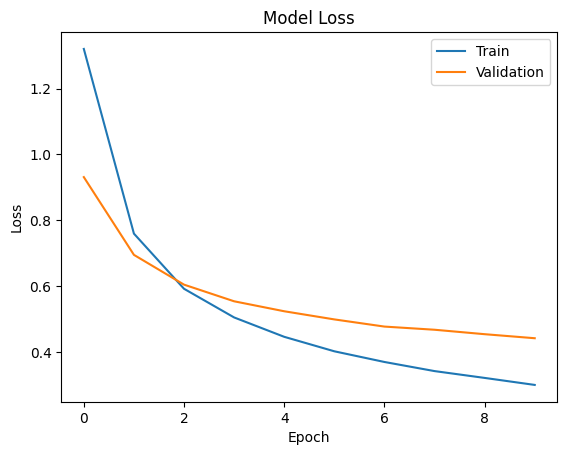

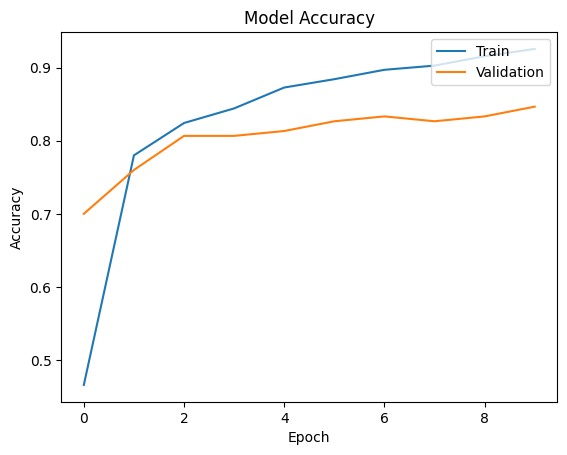

In [33]:
## Your Code
history = model.training_history
# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Plot training & validation accuracy values values
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

### Task 7 Report

The standard transfer-learning curves show that the model is learning from the flower training set. Training loss fell across the 10 epochs and training accuracy increased to 0.926. Validation accuracy also improved overall and finished at 0.847, showing that the frozen MobileNetV2 features were useful for distinguishing the five flower classes.

The validation curve is lower and less smooth than the training curve, which is expected with a small dataset and a randomly initialised final Dense layer. The gap between training and validation accuracy suggests some overfitting, so validation accuracy is more useful than training accuracy when comparing learning rates and momentum settings in the later experiments.

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step - accuracy: 0.5643 - loss: 2.3031 - val_accuracy: 0.8000 - val_loss: 0.6394
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - accuracy: 0.8814 - loss: 0.3340 - val_accuracy: 0.8200 - val_loss: 0.5092
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.9043 - loss: 0.2574 - val_accuracy: 0.8533 - val_loss: 0.4494
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 396ms/step - accuracy: 0.9500 - loss: 0.1614 - val_accuracy: 0.8667 - val_loss: 0.4254
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step - accuracy: 0.9743 - loss: 0.1030 - val_accuracy: 0.8867 - val_loss: 0.3707
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - accuracy: 0.9843 - loss: 0.0819 - val_accuracy: 0.8733 - val_loss: 0.3688
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - accuracy: 0.9914 - loss: 0.0680 - val_accuracy: 0.8667 - val_loss: 0.3774
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step - accuracy: 0.9957 - loss: 0.0556 - val_accuracy: 0

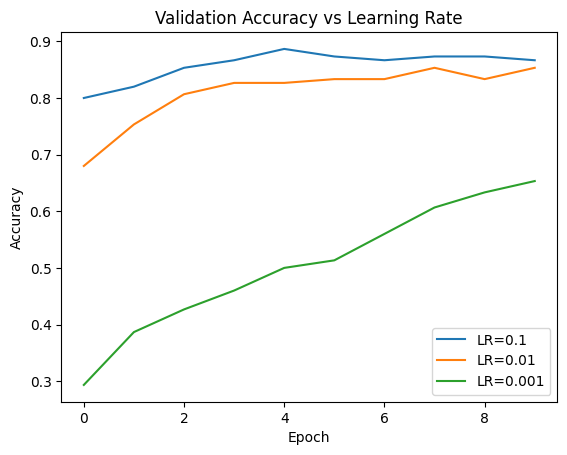

In [34]:
## Your code
## Your code
model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))
history01 = model.training_history

model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))
history001 = model.training_history


model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.001, 0.0, False))
history0001 = model.training_history
#do for lr 0.1, 0.01, 0.001

#plot val accuracy for each
#compare lr
# expectations: 
# lr = 0.1 unstable 
# lr = 0.01 stable
# lr = 0.001 slow, maybe underfit?
plt.plot(history01.history['val_accuracy'], label='LR=0.1')
plt.plot(history001.history['val_accuracy'], label='LR=0.01')
plt.plot(history0001.history['val_accuracy'], label='LR=0.001')

plt.title("Validation Accuracy vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



### Task 8 Analysis and discussion


The learning rate of 0.1 produced the best validation result in this run. It reached a peak validation accuracy of 0.887 and finished at 0.867 after 10 epochs. The learning rate of 0.01 also performed well, finishing at 0.853 validation accuracy, but it improved more gradually. The learning rate of 0.001 was too small for this 10 epoch experiment and only reached 0.653 validation accuracy.

These results show that the larger learning rate allowed the new Dense classifier layer to adapt faster to the flower dataset. Since 0.1 gave the highest validation accuracy among the three learning rates tested, it was used as the best learning rate for the later test-set, k-fold and momentum experiments.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.6086 - loss: 1.6421 - val_accuracy: 0.8133 - val_loss: 0.6896
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.8486 - loss: 0.4069 - val_accuracy: 0.7600 - val_loss: 0.8496
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.9243 - loss: 0.2417 - val_accuracy: 0.8800 - val_loss: 0.3893
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9314 - loss: 0.2528 - val_accuracy: 0.8800 - val_loss: 0.4103
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9671 - loss: 0.1134 - val_accuracy: 0.8867 - val_loss: 0.3823
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.9843 - loss: 0.0735 - val_accuracy: 0.8800 - val_loss: 0.3734
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9957 - loss: 0.0665 - val_accuracy: 0.8800 - val_loss: 0.3770
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.9943 - loss: 0.0589 - val_accuracy: 0.

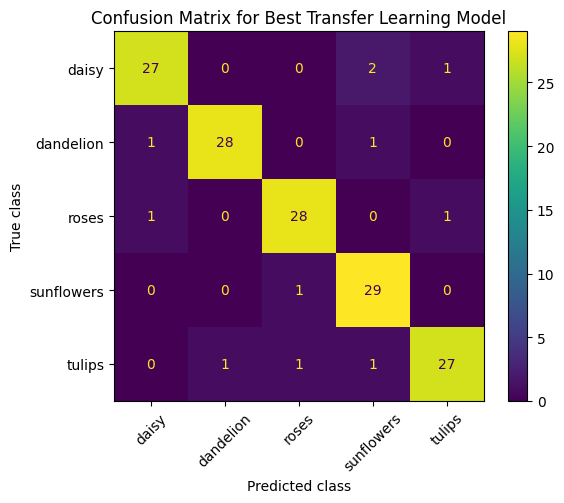

In [35]:


#best model
model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))

#split test data into images, labels
images_test, labels_test = test_set

# predict labels for image (probabilities)
preds = model.predict(images_test)

# Choose max probability 
label_pred = np.argmax(preds, axis = 1)


cm = confusion_matrix(labels_test, label_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=load_data.class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix for Best Transfer Learning Model")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()



In [36]:
class_names = list(load_data.class_names)
print (class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [37]:
# reuse the predictions made in Task 9: labels_test (true) and label_pred (predicted)
class_names = list(load_data.class_names)

# per-class scores (average=None gives one score per flower)
precision = precision_score(labels_test, label_pred, average=None, zero_division=0)
recall    = recall_score(labels_test, label_pred, average=None, zero_division=0)
f1        = f1_score(labels_test, label_pred, average=None, zero_division=0)

# A clean table
print(f"{'Class':<12}{'Precision':>11}{'Recall':>9}{'F1':>8}")
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{name:<12}{precision[i]:>11.3f}{recall[i]:>9.3f}{f1[i]:>8.3f}")

# macro = average across classes equally; weighted = weighted by class size
print("-" * 40)
print(f"{'Macro avg':<12}{precision.mean():>11.3f}{recall.mean():>9.3f}{f1.mean():>8.3f}")

# full sklearn report (includes both averages)
print("\n", classification_report(labels_test, label_pred,
                                  target_names=class_names, digits=3))

Class         Precision   Recall      F1
----------------------------------------
daisy             0.931    0.900   0.915
dandelion         0.966    0.933   0.949
roses             0.933    0.933   0.933
sunflowers        0.879    0.967   0.921
tulips            0.931    0.900   0.915
----------------------------------------
Macro avg         0.928    0.927   0.927

               precision    recall  f1-score   support

       daisy      0.931     0.900     0.915        30
   dandelion      0.966     0.933     0.949        30
       roses      0.933     0.933     0.933        30
  sunflowers      0.879     0.967     0.921        30
      tulips      0.931     0.900     0.915        30

    accuracy                          0.927       150
   macro avg      0.928     0.927     0.927       150
weighted avg      0.928     0.927     0.927       150



## Task 10 Report

Precision, recall and F1 score were computed per class on the test set using the best learning rate (0.1) identified in Task 8.

The model achieved an overall accuracy of 0.927 and a macro-average F1 score of 0.927, indicating strong performance across the five flower classes. The strongest class was dandelion (F1 = 0.949), while the weakest classes were daisy and tulips (both F1 = 0.915). The per-class F1 scores were close together, which suggests that the classifier was not relying heavily on one easy class to achieve a high overall score.

Wherever the precision exceeded recall for a class, the model was cautious. It predicted that class only when confident, missing some true examples. Wherever the recall exceeded precision, the model over-predicted that class.

Overall the balanced F1 scores suggest the classifier generalises reasonably across the five classes given the limited training data.

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [38]:
# classifier with fit() and predict()
# with precomputed features (so k-fold runs in seconds, not hours).

class FlowerClassifier:
    """Trains a Dense(5) head on precomputed 1280-d features."""
    def __init__(self, learning_rate=0.1, momentum=0.0, epochs=10):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.epochs = epochs

    def fit(self, train_features, train_classes):
        # build a fresh one-layer model each time (no leftover learning)
        self.net = keras.Sequential([
            keras.Input(shape=(train_features.shape[1],)),
            keras.layers.Dense(5, activation='softmax')
        ])
        self.net.compile(
            optimizer=keras.optimizers.SGD(learning_rate=self.learning_rate,
                                           momentum=self.momentum),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
        self.net.fit(train_features, train_classes,
                     epochs=self.epochs, batch_size=32, verbose=0)

    def predict(self, test_features):
        # return integer class predictions
        return np.argmax(self.net.predict(test_features, verbose=0), axis=1)


# precompute features F(x) for the WHOLE dataset that runs once
feature_base = load_model()
feature_extractor = keras.Model(feature_base.input, feature_base.layers[-2].output)
F_all = feature_extractor.predict(X, batch_size=64, verbose=1)   # shape (n, 1280)
print("Feature shape:", F_all.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 384ms/step
Feature shape: (1000, 1280)


In [39]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    K-fold cross validation. Returns:
      avg_metrics:   (3, c) -> row0 precision, row1 recall, row2 f1 (per class, averaged over folds)
      sigma_metrics: (3,)   -> std dev of [precision, recall, f1]
    '''
    features = np.asarray(features)
    ground_truth = np.asarray(ground_truth)
    classes = np.unique(ground_truth)          # [0,1,2,3,4]
    n = len(features)

    # split data: shuffle indices then cut into k folds
    indices = np.random.permutation(n)
    folds = np.array_split(indices, k)         # list of k index-arrays

    fold_p, fold_r, fold_f = [], [], []        # store per-class scores each fold

    # go through each partition and use it as the test set
    for partition_no in range(k):
        # determine test and train sets
        test_idx  = folds[partition_no]
        train_idx = np.concatenate([folds[i] for i in range(k) if i != partition_no])

        train_features, train_classes = features[train_idx], ground_truth[train_idx]
        test_features,  test_classes  = features[test_idx],  ground_truth[test_idx]

        # fit model to training data and perform predictions on the test set
        classifier.fit(train_features, train_classes)
        predictions = classifier.predict(test_features)

        # calculate performance metrics (per class)
        fold_p.append(precision_score(test_classes, predictions, average=None,
                                      labels=classes, zero_division=0))
        fold_r.append(recall_score(test_classes, predictions, average=None,
                                   labels=classes, zero_division=0))
        fold_f.append(f1_score(test_classes, predictions, average=None,
                               labels=classes, zero_division=0))

    # perform statistical analyses on metrics
    fold_p, fold_r, fold_f = np.array(fold_p), np.array(fold_r), np.array(fold_f)  # (k, c)
    avg_metrics   = np.vstack([fold_p.mean(0), fold_r.mean(0), fold_f.mean(0)])    # (3, c)
    sigma_metrics = np.array([fold_p.std(), fold_r.std(), fold_f.std()])           # (3,)

    return avg_metrics, sigma_metrics

In [40]:
# run k-fold for three k values using best lr = 0.1
for k in [3, 5, 10]:
    clf = FlowerClassifier(learning_rate=0.1, momentum=0.0, epochs=10)
    avg, sigma = k_fold_validation(F_all, Y, clf, k=k)
    print(f"\n=== k = {k} ===")
    print(f"{'Class':<12}{'Prec':>8}{'Recall':>8}{'F1':>8}")
    for i, name in enumerate(class_names):
        print(f"{name:<12}{avg[0,i]:>8.3f}{avg[1,i]:>8.3f}{avg[2,i]:>8.3f}")
    print(f"Macro F1 = {avg[2].mean():.3f}   |  F1 std across folds = {sigma[2]:.3f}")



=== k = 3 ===
Class           Prec  Recall      F1
daisy          0.881   0.874   0.877
dandelion      0.900   0.914   0.907
roses          0.852   0.817   0.834
sunflowers     0.896   0.858   0.875
tulips         0.789   0.844   0.814
Macro F1 = 0.861   |  F1 std across folds = 0.037

=== k = 5 ===
Class           Prec  Recall      F1
daisy          0.907   0.905   0.904
dandelion      0.905   0.911   0.905
roses          0.845   0.886   0.864
sunflowers     0.894   0.893   0.893
tulips         0.864   0.820   0.840
Macro F1 = 0.881   |  F1 std across folds = 0.042

=== k = 10 ===
Class           Prec  Recall      F1
daisy          0.863   0.868   0.858
dandelion      0.931   0.891   0.907
roses          0.853   0.812   0.822
sunflowers     0.854   0.864   0.856
tulips         0.781   0.831   0.797
Macro F1 = 0.848   |  F1 std across folds = 0.080


## Task 11 Report

K-fold cross validation was run for k = 3, 5 and 10 on precomputed MobileNetV2 features at the best learning rate (0.1).

The macro F1 scores were 0.861 for k=3, 0.881 for k=5 and 0.848 for k=10, with fold-to-fold standard deviations of 0.037, 0.042 and 0.080 respectively.

The single train/test split in Task 9/10 gave a macro F1 of 0.927, which was higher than the k-fold averages. This suggests that the particular test split used in Task 9/10 was likely easier or more favourable than the average split seen during cross validation. The k=5 run gave the best cross-validation macro F1 in this experiment, while k=10 had the largest standard deviation and was therefore the least stable of the three settings tested.

Overall, k-fold validation is more trustworthy than relying only on one split because every image is used in a test fold once. The results show that the model performs well overall, but the final test-set result should be treated as an optimistic single-split estimate rather than the only measure of performance.

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  


--- Training with Momentum = 0.5 ---
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.6600 - loss: 1.5052 - val_accuracy: 0.8133 - val_loss: 0.6763
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.8900 - loss: 0.3106 - val_accuracy: 0.8467 - val_loss: 0.7459
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9400 - loss: 0.1905 - val_accuracy: 0.8600 - val_loss: 0.5486
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.9800 - loss: 0.0761 - val_accuracy: 0.8667 - val_loss: 0.4492
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.9914 - loss: 0.0456 - val_accuracy: 0.8600 - val_loss: 0.4905
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 1.0000 - loss: 0.0297 - val_accuracy: 0.8733 - val_loss: 0.4274
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.9986 - loss: 0.0255 - val_accuracy: 0.8733 - val_loss: 0.4515
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 1.

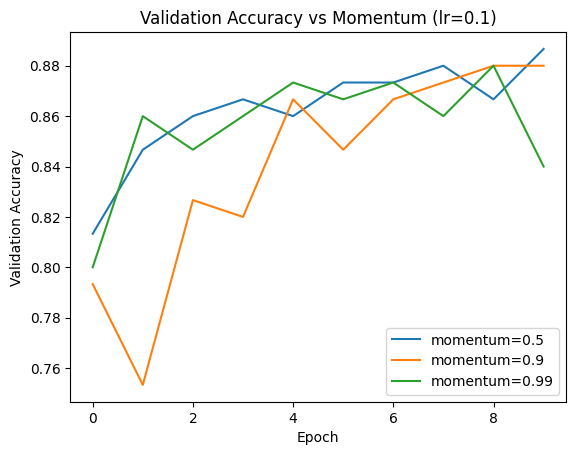


Final validation Accuracy:
 Momentum=0.5: 0.887
 Momentum=0.9: 0.880
 Momentum=0.99: 0.840


In [41]:
momentum_values = [0.5, 0.9, 0.99]
mom_histories = {}

for mom in momentum_values:
    print(f"\n--- Training with Momentum = {mom} ---")
    m = load_model()                                           # fresh model
    m = transfer_learning(train_set, eval_set, m, (0.1, mom, False))
    mom_histories[mom] = m.training_history

# plot validation accuracy for each momentum
for mom in momentum_values:
    plt.plot(mom_histories[mom].history['val_accuracy'], label=f'momentum={mom}')
plt.title("Validation Accuracy vs Momentum (lr=0.1)")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.show()

# print final validation accuracy for each
print("\nFinal validation Accuracy:")
for mom in momentum_values:
    print(f" Momentum={mom}: {mom_histories[mom].history['val_accuracy'][-1]:.3f}")


## Task 12 Report

Using the best learning rate (0.1), momentum was tested at 0.5, 0.9 and 0.99.

Final validation accuracies were 0.887 (m=0.5), 0.880 (m=0.9) and 0.840 (m=0.99). Momentum lets the optimiser keep some of its previous direction, which can improve convergence, but too much momentum can make updates overshoot when the learning rate is already high.

The very high value of 0.99 became less stable: it reached 0.880 validation accuracy during training but dropped to 0.840 by the final epoch and had a much larger validation loss. Momentum values of 0.5 and 0.9 were much closer, but 0.5 produced the best final validation accuracy in this run.

Based on this experiment, momentum = 0.5 is the best choice for this notebook's current results. Although 0.9 is a common default, it was slightly worse than 0.5 here.

## Task 13
Now using "accelerated transfer learning", repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12.

In [42]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Accelerated transfer learning. Precomputes the frozen MobileNetV2 features
    F(x) once, then trains only the Dense(5) classifier on those features.
    Returns the trained classifier (with .training_history and .feature_extractor).
    '''
    learning_rate, momentum, nesterov = parameters

    # F = frozen feature extractor: everything up to the 1280-feature vector
    feature_extractor = keras.Model(model.input, model.layers[-2].output)

    train_images, train_labels = train_set
    eval_images,  eval_labels  = eval_set

    # precompute F(x) ONCE for train and eval images
    t0 = time.time()
    F_train = feature_extractor.predict(train_images, batch_size=64, verbose=0)
    F_eval  = feature_extractor.predict(eval_images,  batch_size=64, verbose=0)
    precompute_time = time.time() - t0
    print(f"Precomputed features in {precompute_time:.1f}s -> F_train {F_train.shape}")

    # N = the new classifier, trained on features 
    classifier = keras.Sequential([
        keras.Input(shape=(F_train.shape[1],)),
        keras.layers.Dense(5, activation='softmax')
    ])
    classifier.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate,
                                       momentum=momentum, nesterov=nesterov),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    # train on precomputed features
    t1 = time.time()
    history = classifier.fit(F_train, train_labels,
                             validation_data=(F_eval, eval_labels),
                             epochs=10, batch_size=32, verbose=1)
    train_time = time.time() - t1
    print(f"Trained classifier in {train_time:.1f}s")

    # store extras for plotting 
    classifier.training_history = history
    classifier.feature_extractor = feature_extractor
    classifier.precompute_time = precompute_time
    classifier.train_time = train_time
    return classifier

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.6800 - loss: 1.6460 - val_accuracy: 0.7933 - val_loss: 1.5632
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.8543 - loss: 1.1937 - val_accuracy: 0.8467 - val_loss: 1.6194
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.9386 - loss: 0.4003 - val_accuracy: 0.8600 - val_loss: 1.4871
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9414 - loss: 0.3077 - val_accuracy: 0.8400 - val_loss: 1.5130
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.9729 - loss: 0.1188 - val_accuracy: 0.8667 - val_loss: 1.7217
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9614 - loss: 0.1974 - val_accuracy: 0.7733 - val_loss: 2.8095
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.9757 - loss: 0.1575 - val_accuracy: 0.8600 - val_loss: 1.8174
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.9943 - loss: 0.0218 - val_accuracy: 0.

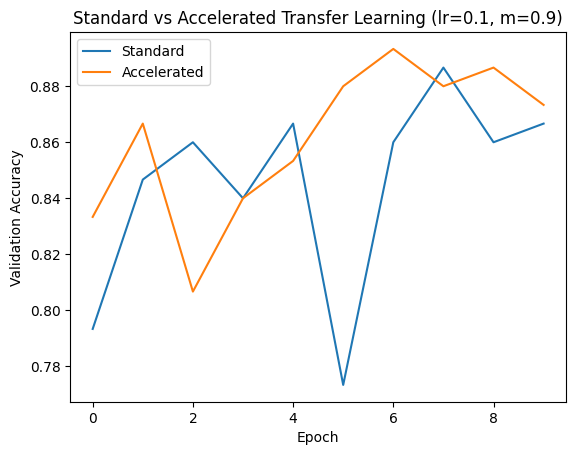

Standard total time:    46.5s
Accelerated total time: 7.5s  (precompute 6.2s + train 1.3s)
Speedup: about 6.2x
Standard final val_accuracy:    0.867
Accelerated final val_accuracy: 0.873


In [43]:
# compare standard vs accelerated at lr=0.1, momentum=0.9

std_base = load_model()
t0 = time.time()
std_model = transfer_learning(train_set, eval_set, std_base, (0.1, 0.9, False))
std_total = time.time() - t0

# accelerated (reuse from above, momentum=0.9)
acc = accelerated_learning(train_set, eval_set, load_model(), (0.1, 0.9, False))
acc_total = acc.precompute_time + acc.train_time

# plot both validation accuracy curves together
plt.plot(std_model.training_history.history['val_accuracy'], label='Standard')
plt.plot(acc.training_history.history['val_accuracy'], label='Accelerated')
plt.title("Standard vs Accelerated Transfer Learning (lr=0.1, m=0.9)")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.show()

print(f"Standard total time:    {std_total:.1f}s")
print(f"Accelerated total time: {acc_total:.1f}s  (precompute {acc.precompute_time:.1f}s + train {acc.train_time:.1f}s)")
print(f"Speedup: about {std_total/acc_total:.1f}x")

# final validation accuracy for both methods (for the Task 13b report)
std_final = std_model.training_history.history['val_accuracy'][-1]
acc_final = acc.training_history.history['val_accuracy'][-1]
print(f"Standard final val_accuracy:    {std_final:.3f}")
print(f"Accelerated final val_accuracy: {acc_final:.3f}")

## Task 13 Report

Accelerated transfer learning was implemented by separating the frozen MobileNetV2 feature extractor from the trainable classifier head. In the standard transfer learning approach, each image is passed through the frozen MobileNetV2 layers during every training epoch before the classifier head is updated. Since the MobileNetV2 backbone is frozen, its output features do not change during training. Therefore, in the accelerated approach, the frozen feature outputs F(x) were precomputed once for the training and validation images, and the classifier head was then trained directly on these feature vectors.

This follows the assignment's accelerated transfer learning idea, where the model is treated as N(F(x)): F(x) represents the frozen MobileNetV2 feature extractor and N(x) represents the new trainable classifier layers. By precomputing F(x), the model avoids recalculating the same frozen features during every training epoch.

The standard transfer learning run took 46.5 seconds, while the accelerated transfer learning run took 7.5 seconds (6.2 seconds to precompute features and 1.3 seconds to train the classifier). This produced a speedup of approximately 6.2x. This shows that most of the training time in the standard implementation came from repeatedly passing images through the frozen MobileNetV2 feature extractor. The accelerated method was much faster because it only trained the classifier head after the feature vectors had been generated.

The final validation accuracy also remained comparable. The standard transfer learning model achieved a final validation accuracy of 0.867, while the accelerated model achieved 0.873. This small difference does not prove that accelerated transfer learning is more accurate overall, because training results can vary slightly between runs. However, it does show that the accelerated approach did not reduce model performance in this experiment.

Overall, accelerated transfer learning was more computationally efficient while maintaining similar classification performance. For this assignment dataset, it is a practical approach because MobileNetV2 is frozen and the dataset is small enough for the extracted feature vectors to be stored and reused. The main limitation is that this method is only appropriate while the feature extractor remains frozen. If fine-tuning were performed later by unfreezing some MobileNetV2 layers, the feature outputs F(x) would change during training and would need to be recomputed.

## Task 14 Conclusion and Recommendations

This project used transfer learning with a frozen MobileNetV2 backbone and a new Dense(5) classifier to identify five flower species.

Recommended parameters, based on our experiments:
- Learning rate: 0.1 gave the best and fastest convergence in Task 8. It reached a peak validation accuracy of 0.887, compared with 0.853 for 0.01 and 0.653 for 0.001.
- Momentum: 0.5 gave the best final validation accuracy in Task 12 (0.887). Momentum = 0.9 was close at 0.880, while 0.99 was less stable and finished lower at 0.840.
- Training method: accelerated learning is recommended because it matched the standard method's validation accuracy closely while reducing runtime from 46.5 seconds to 7.5 seconds, a 6.2x speedup (Task 13).

K-fold validation (Task 11) gave macro F1 scores of 0.861, 0.881 and 0.848 for k=3, k=5 and k=10. These were lower than the single test split's macro F1 of 0.927, suggesting that the final test split was favourable and that k-fold validation gives a more conservative estimate of generalisation.

Limitations: the dataset is small (200 images per class), so more data would likely improve accuracy. Performance was measured on clean images and may drop on real-world photos with poor lighting or unusual angles. The model only knows the 5 trained classes.

Exact values vary slightly between runs due to the random train/validation split and random weight initialisation. The figures reported here are from the saved clean run in this notebook.

Future work: data augmentation (flips, rotations, brightness) to improve robustness; optional fine-tuning of the top MobileNetV2 layers at a very low learning rate; and a larger, more varied dataset for deployment.

## Task 15 Group Contribution Breakdown

The work was divided into three roughly equal blocks so that each member owned a
coherent stage of the pipeline rather than scattered pieces. The split was agreed
early and tracked against internal deadlines, and the table below reflects each
person's specific code and report contributions.

| Member | Student No. | Tasks | Specific Contributions |
|--------|------------|-------|------------------------|
| Nour Spear | n11285915 | 2, 3a, 3b, 4, 5, 6a, 6b | Implemented load_data() to load and preprocess the flower dataset; implemented split_data() with per-class balanced 70/15/15 splitting and wrote the split-strategy report; implemented load_model() and the Dense(5) classifier replacement in replace_classification_layer(); built the baseline transfer_learning() training routine; wrote the transfer_learning explanation and the final technical conclusion. |
| Joshua Oates | n11323442 | 7a, 7b, 8a, 8b, 9, 10b | Produced the training/validation accuracy and loss plots for standard transfer learning and interpreted them; ran the three learning-rate experiments (0.1, 0.01, 0.001) and wrote the comparison selecting 0.1 as best; generated the test-set confusion matrix and interpreted the strongest/weakest classes and confusion patterns. |
| Joshua George | n12116785 | 10a, 11a, 11b, 12a, 12b, 13a, 13b, 14, 15 | Computed per-class precision, recall and F1 on the test set; implemented k_fold_validation() with a reusable classifier wrapper and ran it for k=3, 5 and 10; ran the three momentum experiments and discussed their effect; implemented accelerated_learning() using precomputed frozen features and compared it against standard training for speed and accuracy; wrote this contribution breakdown. |

**Workload justification.** Each member carried close to one third of the marks:
Nour focused on the data pipeline and model setup (the foundation everything else
depends on), Joshua Oates handled the baseline evaluation and learning-rate tuning,
and Joshua George covered the deeper evaluation metrics, validation and the
accelerated-learning optimisation. The two largest single tasks was the classifier
setup (Task 5) and accelerated learning (Task 13). They were placed in different
members' blocks to keep effort balanced.

**Collaboration strategy.** The team communicated through Discord and shared a
single working notebook, agreeing on consistent conventions early (integer labels
with sparse_categorical_crossentropy, the (images, labels) tuple format from
split_data, and lr=0.1 as the agreed best learning rate) so that each member's
code interfaced without modification. Internal deadlines were set ahead of the
final due date, and a joint integration session was held to confirm the notebook
runs cleanly from top to bottom before submission.